# Jalon 1 & 2 — Data & EDA

## Jalon 1 : Choix et justification du dataset

**Dataset** : *TikTok & Instagram Addiction Dataset (2015–2060)* — Kaggle / Abdul Malik Lodhra  
**Licence** : CC BY-NC-SA 4.0  

### Pourquoi ce dataset ?
| Contrainte du sujet | Ce dataset |
|---|---|
| Tâche supervisée claire | `addiction_score` continu (régression) ou `addiction_level` (classification 3 classes) |
| Adapté au DL fondamental (MLP) | 19 features numériques/catégoriques tabulaires → MLP naturel |
| Adapté au DL avancé | Série temporelle 2015–2060 par pays → LSTM/Transformer |
| Volume suffisant | 10 000 lignes (fichier principal) + 50 000 (comportements) |
| Pas dans le repo Git | Dataset exclu via `.gitignore` |

**Tâche principale choisie** : prédiction de `addiction_score` (régression, 0–100).  
Ce choix permet d'utiliser Ridge/Lasso/ElasticNet nativement (régularisation L2/L1) et de faire du forecasting LSTM.

---

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_data, FEATURES, TARGET

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = load_data('../data/tiktok_instagram_global_100countries.csv')
print(f'Dimensions : {df.shape}')
df.head(3)

Dimensions : (10000, 23)


,user_id,country,age,year,internet_penetration,mental_health_support_index,gdp_index,youth_population_ratio,baseline_addiction_pressure,tiktok_minutes_daily,...,addiction_pressure,attention_span_score,dopamine_dependency_score,impulsivity_index,sleep_hours,sleep_quality_index,ASI,MHRI,addiction_score,addiction_level
0,1,Philippines,59,2050,88.895513,64.347080,0.312067,0.310389,64.762693,242.853130,...,69.981792,77.479304,27.024835,60.044856,6.561778,7.912360,100.0,40.460626,63.512418,High
1,2,Netherlands,23,2035,57.950292,76.257045,0.460320,0.293134,37.592646,98.599951,...,56.862382,78.852713,25.376744,81.769114,9.400197,2.292106,100.0,79.424028,62.688372,High
2,3,Laos,26,2060,40.325805,55.846514,0.893658,0.183055,22.589595,127.221573,...,41.817693,83.573012,19.712386,99.613065,7.810417,2.308761,100.0,88.262729,59.856193,High


## Jalon 2 — EDA
### 2.1 Aperçu général, types et valeurs manquantes

In [2]:
print('=== Types de données ===')
print(df.dtypes)
print('\n=== Valeurs manquantes ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Aucune valeur manquante')
print(f'\nDoublons : {df.duplicated().sum()}')

=== Types de données ===
user_id                          int64
country                            str
age                              int64
year                             int64
internet_penetration           float64
mental_health_support_index    float64
gdp_index                      float64
youth_population_ratio         float64
baseline_addiction_pressure    float64
tiktok_minutes_daily           float64
instagram_minutes_daily        float64
night_usage_ratio              float64
scroll_velocity                float64
addiction_pressure             float64
attention_span_score           float64
dopamine_dependency_score      float64
impulsivity_index              float64
sleep_hours                    float64
sleep_quality_index            float64
ASI                            float64
MHRI                           float64
addiction_score                float64
addiction_level                    str
dtype: object

=== Valeurs manquantes ===
Aucune valeur manquante

Doublons : 

In [3]:
df.describe().round(2)

,user_id,age,year,internet_penetration,mental_health_support_index,gdp_index,youth_population_ratio,baseline_addiction_pressure,tiktok_minutes_daily,instagram_minutes_daily,...,scroll_velocity,addiction_pressure,attention_span_score,dopamine_dependency_score,impulsivity_index,sleep_hours,sleep_quality_index,ASI,MHRI,addiction_score
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,...,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,35.74,2037.44,67.95,55.19,0.61,0.32,51.09,120.92,100.11,...,2.99,61.17,81.58,22.10,49.83,7.00,5.97,94.99,45.09,58.55
std,2886.90,13.50,13.22,17.38,20.45,0.23,0.10,19.13,58.32,49.32,...,0.98,20.06,6.42,7.70,29.09,1.46,2.29,12.66,18.60,9.27
min,1.00,13.00,2015.00,40.33,20.49,0.20,0.16,20.65,0.00,0.00,...,0.50,20.77,58.11,0.00,0.01,3.00,2.00,8.03,0.89,4.14
25%,2500.75,24.00,2026.00,51.56,36.94,0.42,0.24,33.42,79.61,66.10,...,2.33,43.61,77.19,16.75,24.66,5.99,3.97,100.00,31.56,57.96
50%,5000.50,35.00,2037.00,67.86,55.60,0.65,0.33,51.66,120.42,99.61,...,3.00,61.65,81.67,21.99,49.47,6.99,5.97,100.00,45.11,61.00
75%,7500.25,47.00,2049.00,83.05,74.59,0.80,0.41,68.77,161.26,133.42,...,3.66,78.59,86.04,27.37,75.30,8.04,7.93,100.00,58.69,63.68
max,10000.00,59.00,2060.00,98.23,89.00,0.99,0.50,79.58,356.31,277.10,...,6.55,99.29,100.00,50.27,99.99,10.00,10.00,100.00,88.94,75.14


### 2.2 Distribution de la variable cible

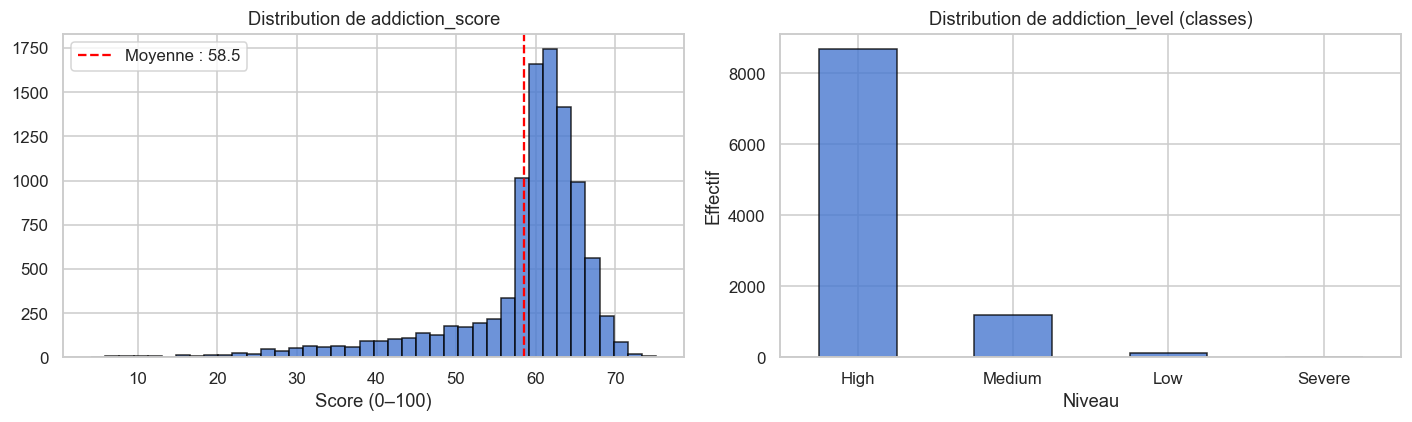

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['addiction_score'], bins=40, edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution de addiction_score')
axes[0].set_xlabel('Score (0–100)')
axes[0].axvline(df['addiction_score'].mean(), color='red', linestyle='--', label=f'Moyenne : {df["addiction_score"].mean():.1f}')
axes[0].legend()

df['addiction_level'].value_counts().plot.bar(ax=axes[1], edgecolor='black', alpha=0.8)
axes[1].set_title('Distribution de addiction_level (classes)')
axes[1].set_xlabel('Niveau')
axes[1].set_ylabel('Effectif')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 2.3 Distributions des features numériques

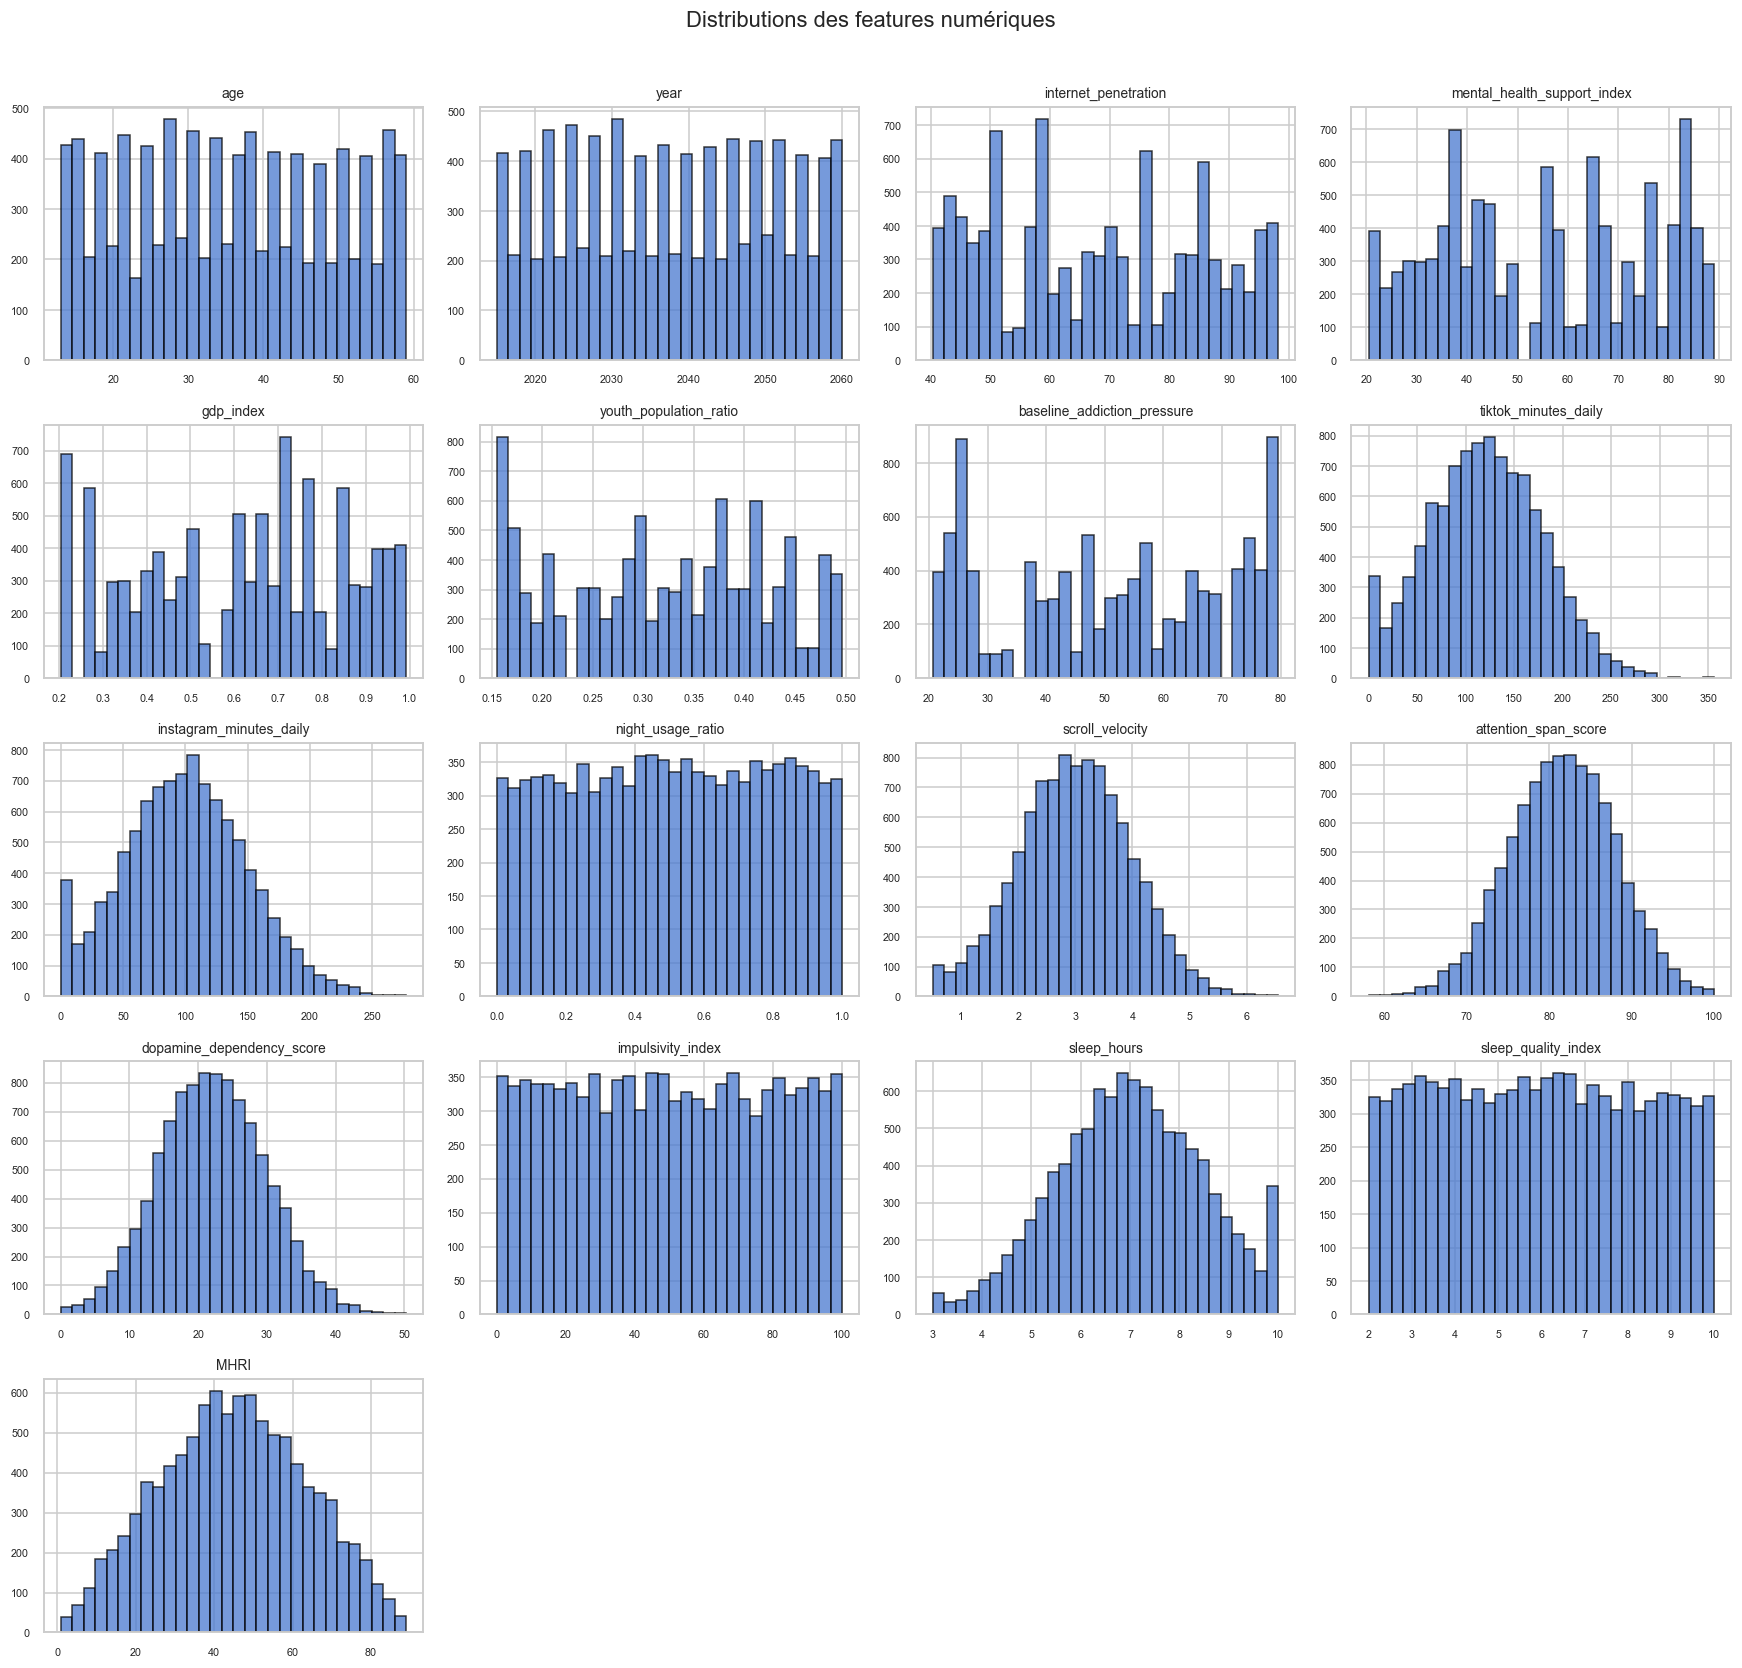

In [5]:
num_cols = [c for c in FEATURES if c != 'country_enc']
n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.75)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des features numériques', y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Matrice de corrélation

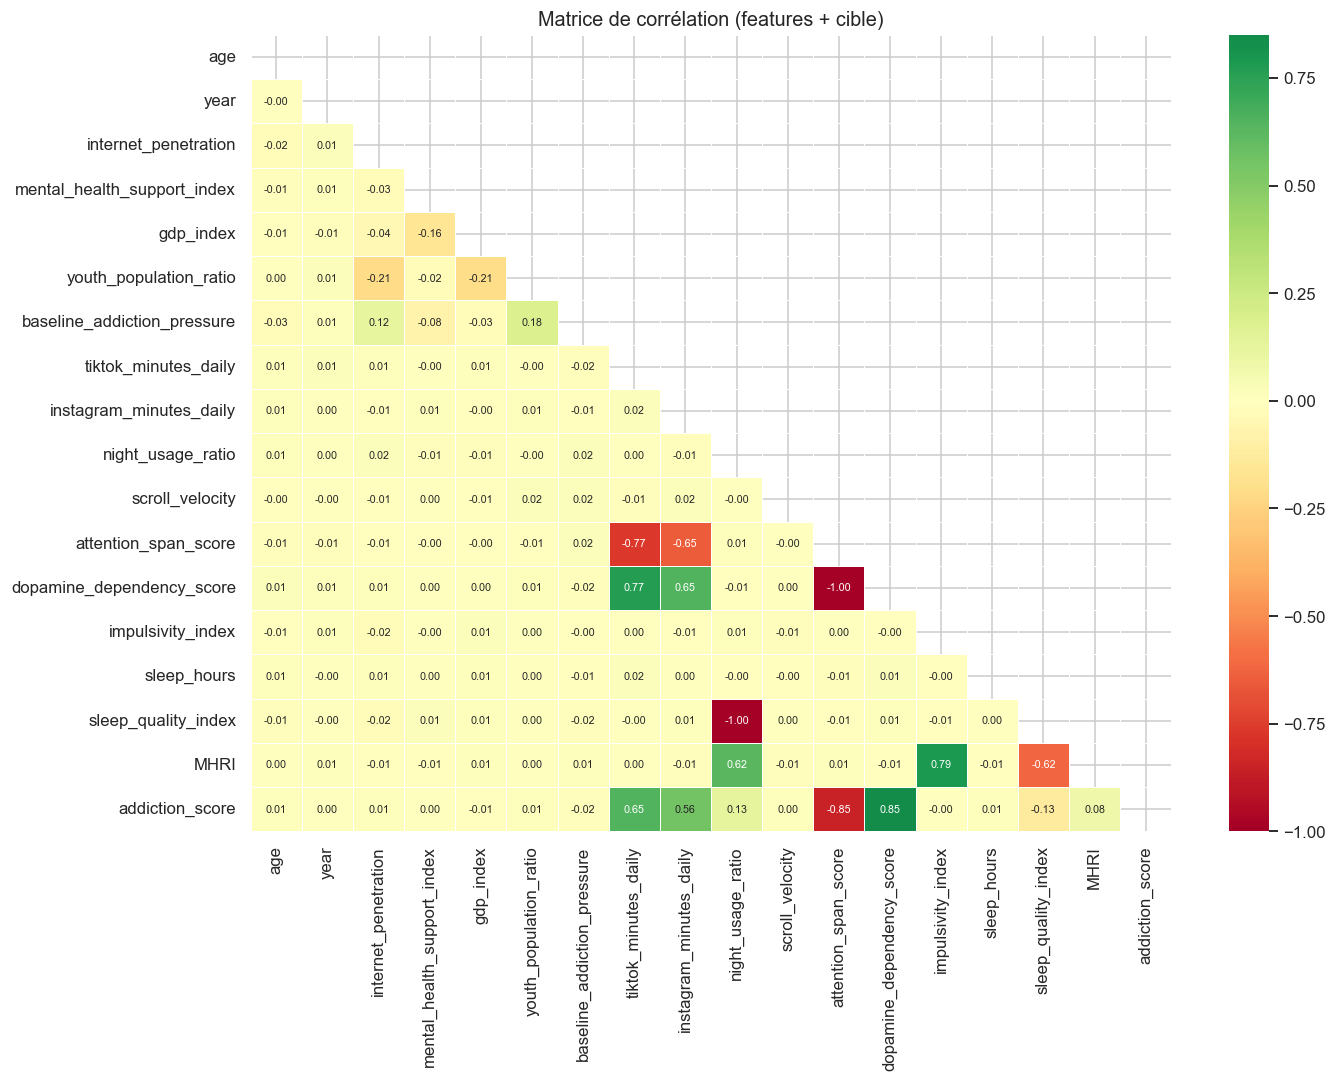


Top corrélations avec addiction_score :
attention_span_score           0.850410
dopamine_dependency_score      0.850410
tiktok_minutes_daily           0.652969
instagram_minutes_daily        0.555435
sleep_quality_index            0.131937
night_usage_ratio              0.131937
MHRI                           0.080394
baseline_addiction_pressure    0.016115
Name: addiction_score, dtype: float64


In [6]:
corr_cols = num_cols + ['addiction_score']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Matrice de corrélation (features + cible)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTop corrélations avec addiction_score :')
print(corr_matrix['addiction_score'].drop('addiction_score').abs().sort_values(ascending=False).head(8))

### 2.5 Tendances temporelles (2015–2060)

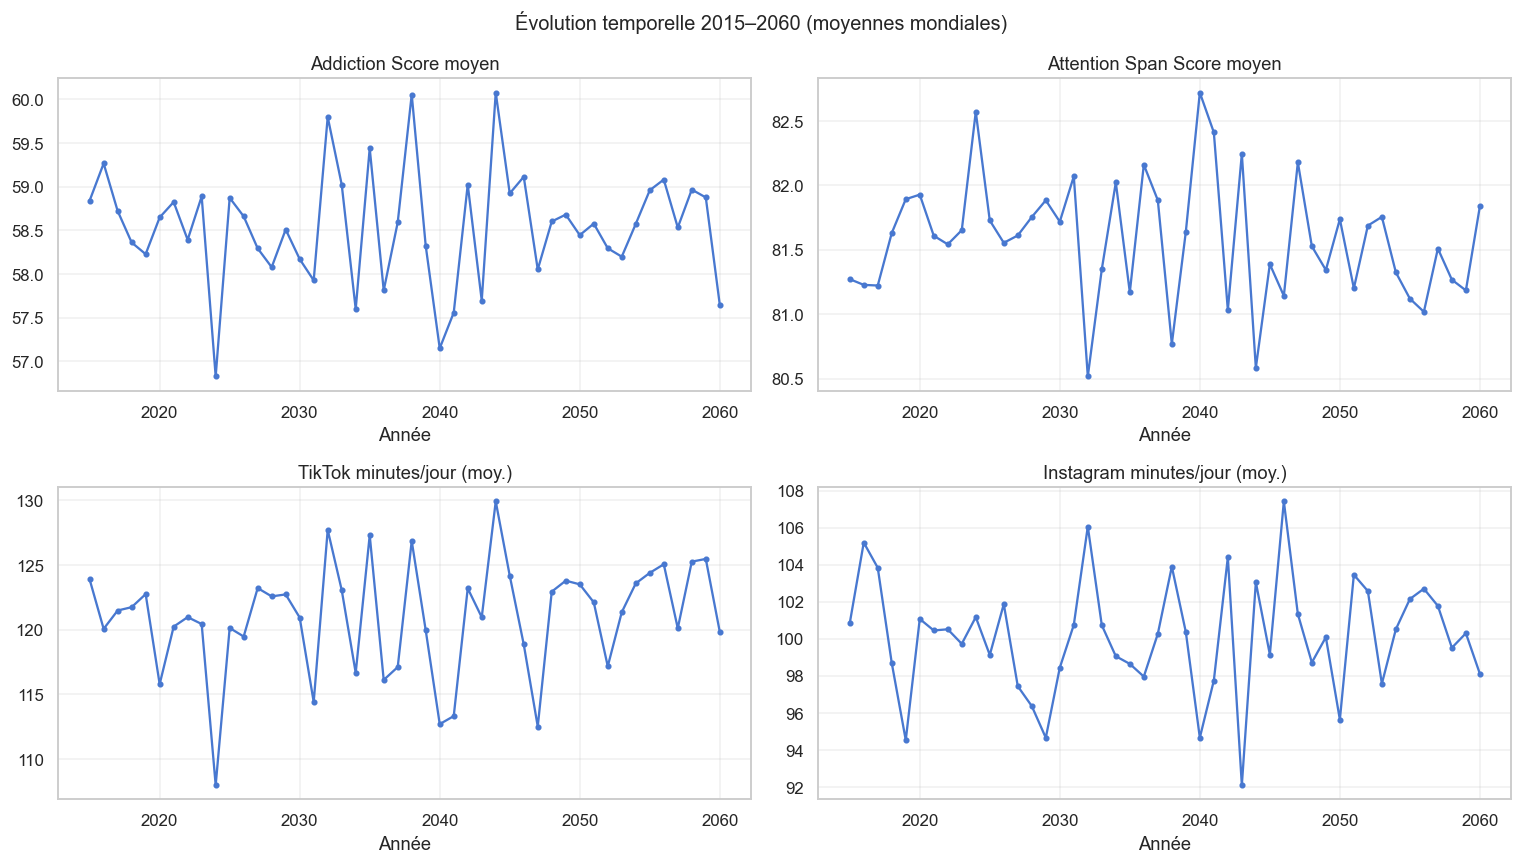

In [7]:
yearly = df.groupby('year')[['addiction_score', 'attention_span_score', 'tiktok_minutes_daily', 'instagram_minutes_daily']].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cols_plot = {
    'addiction_score': 'Addiction Score moyen',
    'attention_span_score': 'Attention Span Score moyen',
    'tiktok_minutes_daily': 'TikTok minutes/jour (moy.)',
    'instagram_minutes_daily': 'Instagram minutes/jour (moy.)'
}
for ax, (col, title) in zip(axes.flatten(), cols_plot.items()):
    ax.plot(yearly.index, yearly[col], marker='o', markersize=3)
    ax.set_title(title)
    ax.set_xlabel('Année')
    ax.grid(True, alpha=0.3)

plt.suptitle('Évolution temporelle 2015–2060 (moyennes mondiales)', fontsize=13)
plt.tight_layout()
plt.show()

### 2.6 Analyse par pays — Top 15 pays par addiction

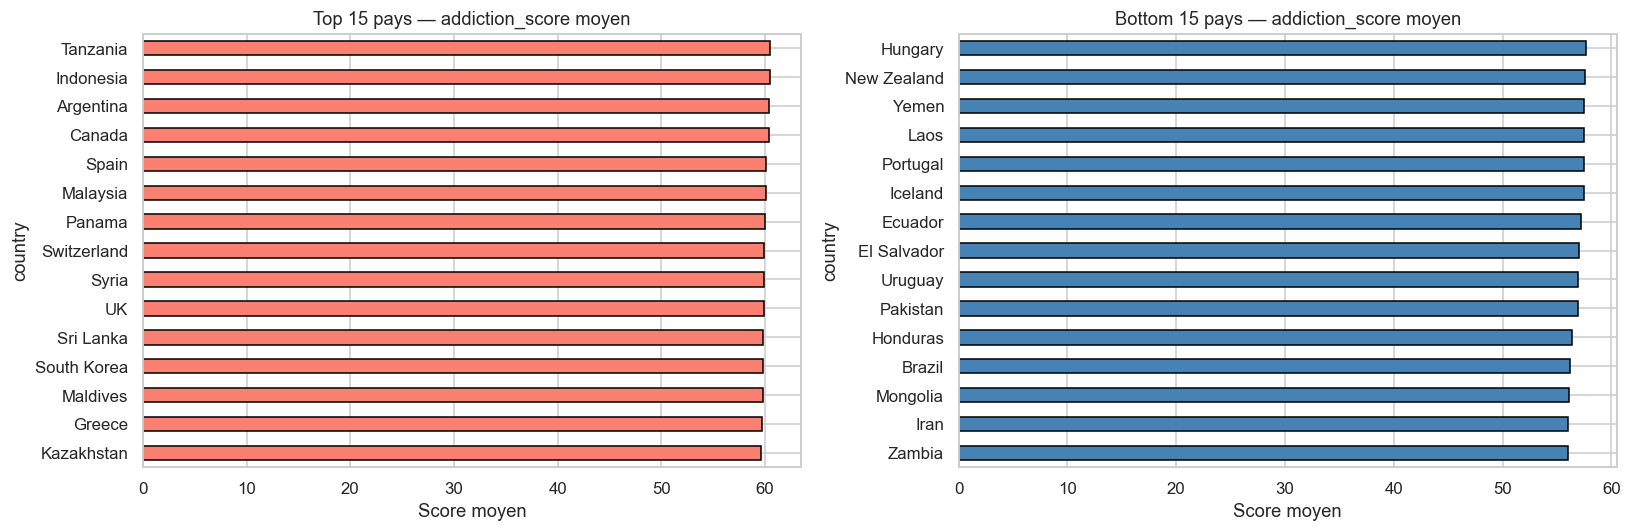

In [8]:
country_mean = df.groupby('country')['addiction_score'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

country_mean.head(15).plot.barh(ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Top 15 pays — addiction_score moyen')
axes[0].invert_yaxis()
axes[0].set_xlabel('Score moyen')

country_mean.tail(15).plot.barh(ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Bottom 15 pays — addiction_score moyen')
axes[1].invert_yaxis()
axes[1].set_xlabel('Score moyen')

plt.tight_layout()
plt.show()

### 2.7 Détection des anomalies (méthode IQR)

Nombre de valeurs aberrantes par feature (méthode IQR) :
instagram_minutes_daily      42
dopamine_dependency_score    40
attention_span_score         40
scroll_velocity              37
tiktok_minutes_daily         29
dtype: int64


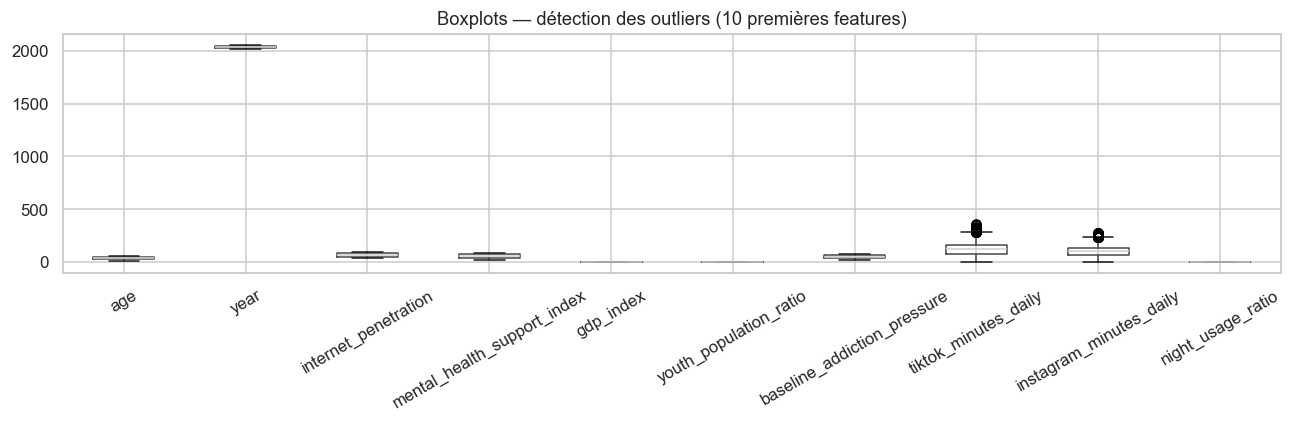

In [9]:
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum()

outlier_counts = {col: iqr_outliers(df[col]) for col in num_cols}
outlier_df = pd.Series(outlier_counts).sort_values(ascending=False)
print('Nombre de valeurs aberrantes par feature (méthode IQR) :')
print(outlier_df[outlier_df > 0])

fig, ax = plt.subplots(figsize=(12, 4))
df[num_cols[:10]].boxplot(ax=ax, vert=True)
ax.set_title('Boxplots — détection des outliers (10 premières features)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 2.8 Analyse par groupe d'âge (dataset screen_time)

Le fichier `screen_time_behavior.csv` (50 000 lignes) apporte une dimension démographique complémentaire.

Dimensions screen_time : (50000, 11)


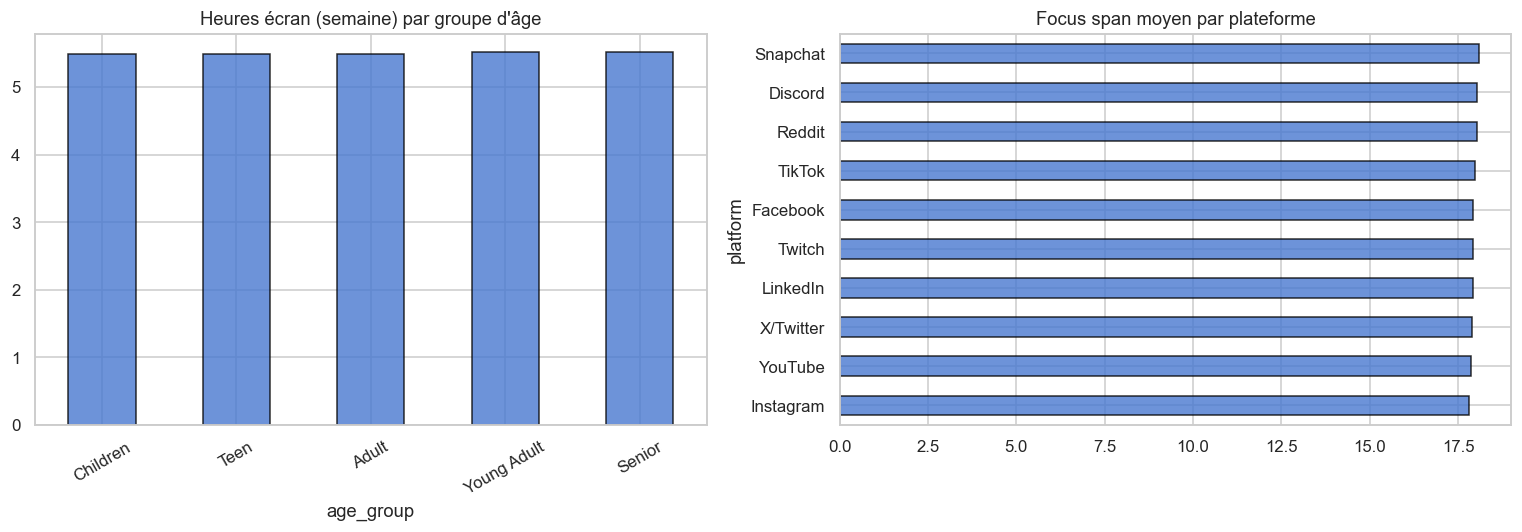

In [10]:
df_screen = pd.read_csv('../data/screen_time_behavior.csv')
print(f'Dimensions screen_time : {df_screen.shape}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_screen.groupby('age_group')['weekday_screen_hours'].mean().sort_values().plot.bar(
    ax=axes[0], edgecolor='black', alpha=0.8
)
axes[0].set_title('Heures écran (semaine) par groupe d\'âge')
axes[0].tick_params(axis='x', rotation=30)

df_screen.groupby('platform')['focus_span_minutes'].mean().sort_values().plot.barh(
    ax=axes[1], edgecolor='black', alpha=0.8
)
axes[1].set_title('Focus span moyen par plateforme')

plt.tight_layout()
plt.show()

## Synthèse EDA

| Observation | Impact sur la modélisation |
|---|---|
| Pas de valeurs manquantes | Pas de stratégie d'imputation nécessaire |
| `addiction_score` distribué sur toute la plage 0–100 | Tâche de régression directe |
| Forte corrélation `tiktok_minutes_daily` ↔ `addiction_score` | Feature importante pour le modèle |
| Tendance haussière 2015→2060 | Structure temporelle exploitable par LSTM |
| Dataset synthétique | Résultats de haute performance attendus |
| Peu d'outliers significatifs | StandardScaler suffisant, pas de winsorisation nécessaire |